# Visualization Module Test

Tests the overhauled `visualize.py` module: movies, static frames, multi-panel,
and different scaling/mask options.

Uses a small Sentinel-2 stack from Planetary Computer.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pystac_client
import planetary_computer
from IPython.display import Video, display

from sat_tile_stack import sattile_stack
from sat_tile_stack.visualize import (
    timestack_to_movie, export_frame, multi_panel_frame, batch_movies
)

print("Imports OK")

Imports OK


## Build a test stack

Greenland lake, 2 weeks of S2 data, 128x128 tile, with SCL for cloud masking.

In [2]:
import pandas as pd
import geopandas as gpd
from shapely import wkt

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

CENTROID = (-49.4957449, 68.72493445)

# Load a lake polygon near this centroid for the mask overlay
df = pd.read_csv("../data/labels_2019_volumes_CW.csv")
df["geometry"] = df["geometry"].apply(wkt.loads)
gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

# Find the lake closest to our centroid
from shapely.geometry import Point
target = Point(CENTROID)
gdf["dist"] = gdf.geometry.centroid.distance(target)
lake_gdf = gdf.nsmallest(1, "dist")
print(f"Using lake: {lake_gdf.iloc[0]['new_id']} (dist={lake_gdf.iloc[0]['dist']:.4f} deg)")

stack = sattile_stack(
    catalog, CENTROID,
    band_names=["B04", "B03", "B02", "B08", "B11", "SCL"],
    collection="sentinel-2-l2a",
    pix_res=20, tile_size=128,
    time_range="2019-06-01/2019-06-14",
    normalize=False,
    cloudmask="scl",
    mask=lake_gdf,
    pull_to_mem=True,
)

print(f"Stack shape: {stack.shape}")
print(f"Bands: {list(stack.band.values)}")
print(f"Time steps: {len(stack.time)}")

/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_85312/3544179019.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["dist"] = gdf.geometry.centroid.distance(target)
/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_85312/3544179019.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["dist"] = gdf.geometry.centroid.distance(target)


Using lake: CW2019_1889 (dist=0.0000 deg)
Pulling stack into memory, shape: (14, 8, 128, 128)
[########################################] | 100% Completed | 12.95 s
Stack loaded, shape: (14, 8, 128, 128)
Stack shape: (14, 8, 128, 128)
Bands: ['B04', 'B03', 'B02', 'B08', 'B11', 'SCL', 'cloudmask', 'mask']
Time steps: 14


## Test 1: Static frame — default (True Color, /10000 scaling)

First timestep with data: index 0


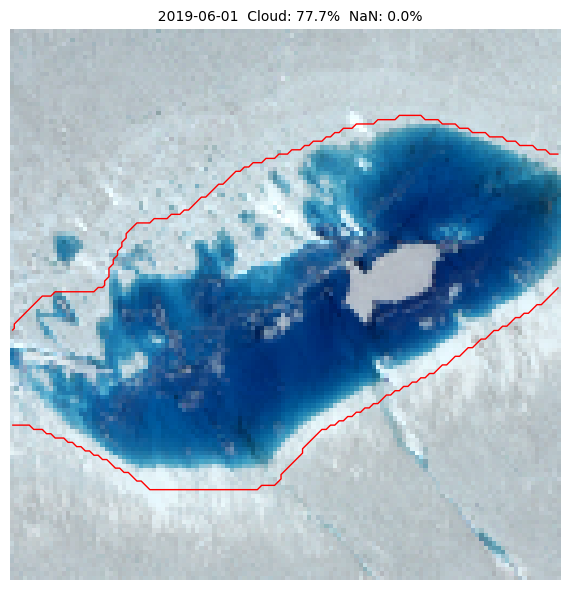

In [3]:
# Find first timestep with data
for i in range(len(stack.time)):
    if not np.isnan(stack.isel(time=i).sel(band="B04").values).all():
        break
print(f"First timestep with data: index {i}")

export_frame(stack, time_index=i, bands=("B04", "B03", "B02"),
             scale="divide", mask_band="mask", mask_mode="static")

## Test 2: Static frame — percentile stretch

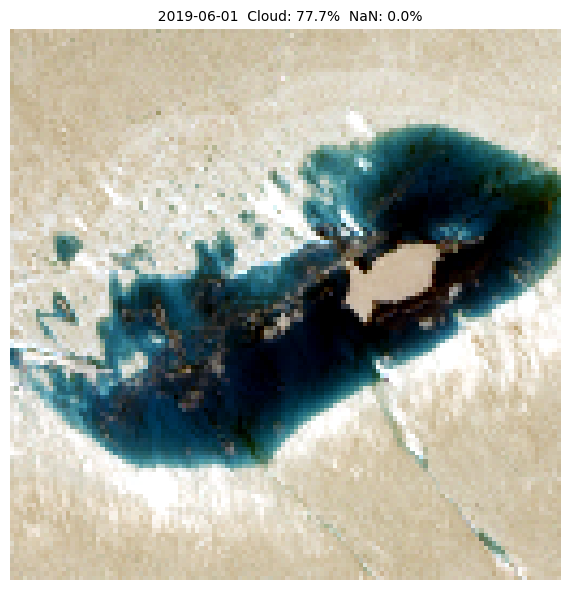

In [4]:
export_frame(stack, time_index=i, bands=("B04", "B03", "B02"),
             scale="percentile", mask_band=None)

## Test 3: Static frame — false color (SWIR/NIR/Red)

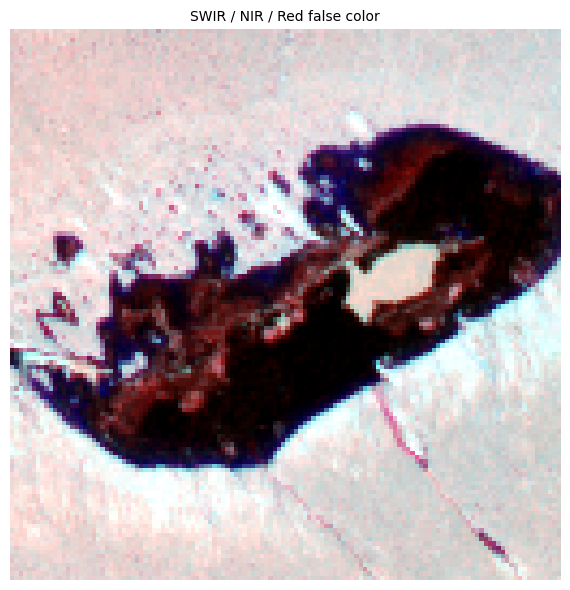

In [5]:
export_frame(stack, time_index=i, bands=("B11", "B08", "B04"),
             scale="percentile", mask_band=None,
             title="SWIR / NIR / Red false color")

## Test 4: Multi-panel — True Color + False Color + Cloud Mask

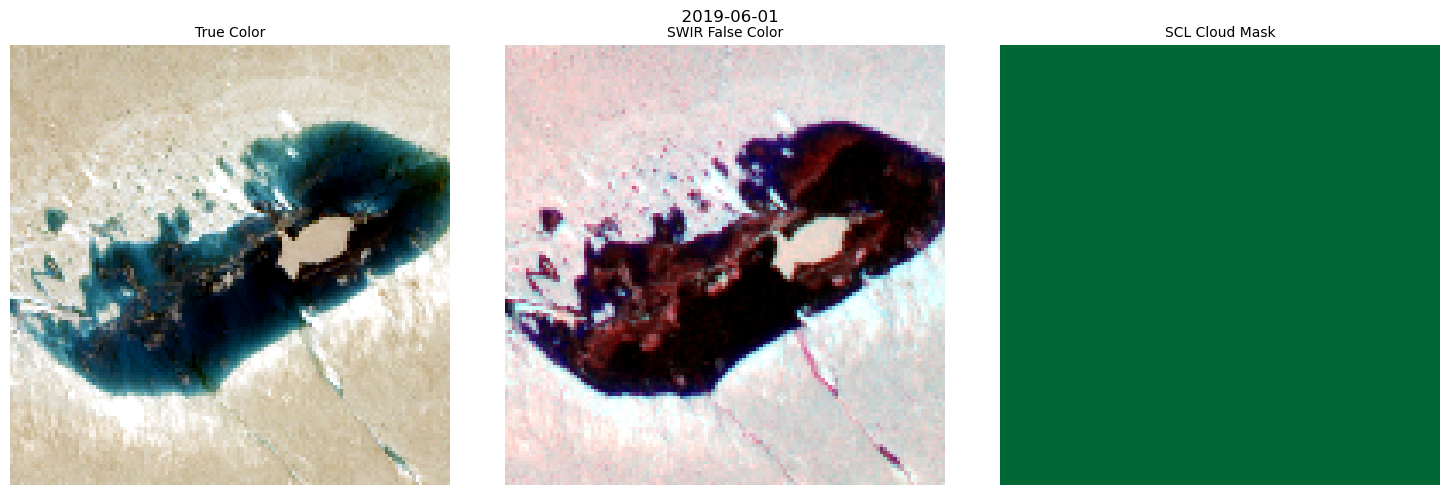

In [6]:
multi_panel_frame(stack, time_index=i, panels=[
    {"bands": ["B04", "B03", "B02"], "label": "True Color", "scale": "percentile"},
    {"bands": ["B11", "B08", "B04"], "label": "SWIR False Color", "scale": "percentile"},
    {"bands": ["cloudmask"], "label": "SCL Cloud Mask", "cmap": "RdYlGn_r"},
], mask_band=None)

## Test 5: Movie — True Color with static mask overlay

In [7]:
timestack_to_movie(
    stack, bands=("B04", "B03", "B02"),
    scale="divide",
    mask_band="mask", mask_mode="static", mask_color="red",
    fps=2, skip_empty=False,
    outfile="output/test_truecolor.mp4",
    dpi=100,
)

Saved output/test_truecolor.mp4 (14 frames, 2 fps)


In [8]:
# Display the movie inline
display(Video("output/test_truecolor.mp4", embed=True, width=400))

## Test 6: Movie — False Color with percentile stretch

In [9]:
timestack_to_movie(
    stack, bands=("B11", "B08", "B04"),
    scale="percentile", mask_band=None,
    fps=2, skip_empty=True,
    outfile="output/test_falsecolor.mp4",
    dpi=100,
)

Saved output/test_falsecolor.mp4 (11 frames, 2 fps)


In [10]:
display(Video("output/test_falsecolor.mp4", embed=True, width=400))

## Test 7: Movie — all frames (including empty/NaN days)

In [11]:
timestack_to_movie(
    stack, bands=("B04", "B03", "B02"),
    scale="divide", mask_band=None,
    fps=4, skip_empty=False,
    outfile="output/test_with_empty.mp4",
    dpi=100,
)

Saved output/test_with_empty.mp4 (14 frames, 4 fps)


In [12]:
display(Video("output/test_with_empty.mp4", embed=True, width=400))

## Test 8: Save frame as PNG

Saved frame: output/test_frame.png


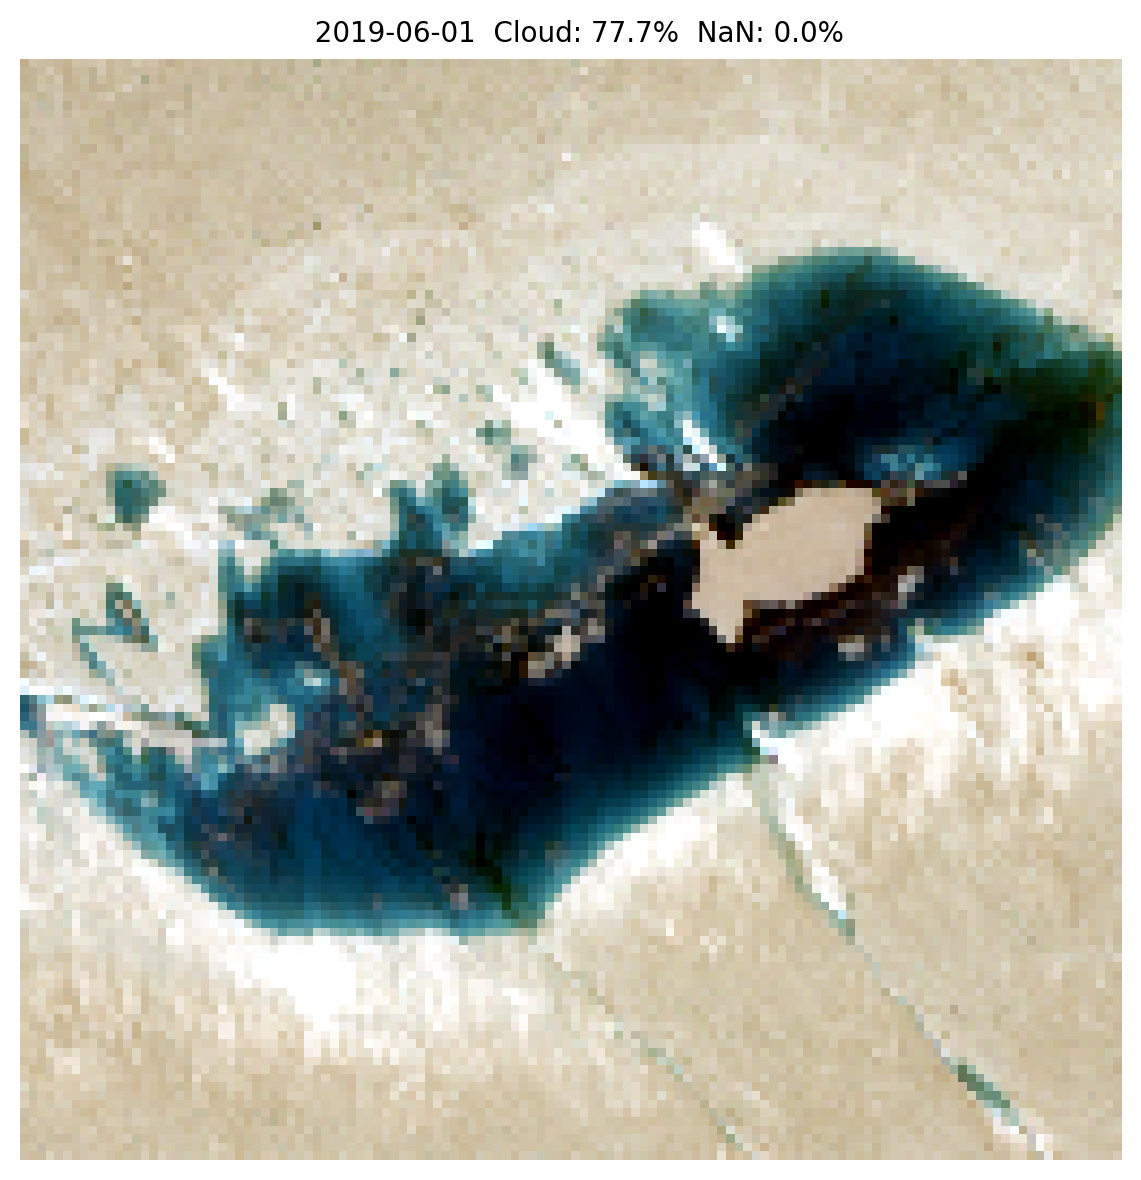

In [13]:
export_frame(
    stack, time_index=i,
    bands=("B04", "B03", "B02"),
    scale="percentile",
    mask_band=None,
    outfile="output/test_frame.png",
    dpi=200,
)

from IPython.display import Image
display(Image("output/test_frame.png", width=400))

## Summary

In [14]:
print("="*50)
print("VISUALIZATION TESTS COMPLETE")
print("="*50)
print()
print("Tested:")
print("  1. Static frame — /10000 scaling")
print("  2. Static frame — percentile stretch")
print("  3. Static frame — SWIR false color")
print("  4. Multi-panel (true color + false color + cloud mask)")
print("  5. Movie — true color, skip empty")
print("  6. Movie — false color, percentile")
print("  7. Movie — all frames including empty")
print("  8. Save frame as PNG")

VISUALIZATION TESTS COMPLETE

Tested:
  1. Static frame — /10000 scaling
  2. Static frame — percentile stretch
  3. Static frame — SWIR false color
  4. Multi-panel (true color + false color + cloud mask)
  5. Movie — true color, skip empty
  6. Movie — false color, percentile
  7. Movie — all frames including empty
  8. Save frame as PNG
